# IMAGE CAPTION GENERATOR

In this project, we developed an Image Caption Generator using deep learning techniques. The aim was to build a model that can generate meaningful textual descriptions for given input images. This project involved collecting a dataset of images and their corresponding captions, training a deep learning model, and integrating it into a web application.

To start, we gathered a dataset of images and their associated captions. Once we have completed the data collection process, we proceeded to build the Image Caption Generator model.
For the deep learning aspect, we utilized convolutional neural networks (CNNs) and recurrent neural networks (RNNs) in combination. CNNs were used to extract meaningful features from the input images, while RNNs, specifically Long Short-Term Memory (LSTM) networks, were employed to generate captions based on the extracted features.

### IMPORTING NECESSARY LIBRARIES

In [6]:
import os
import pickle
import numpy as np
from tqdm.notebook import tqdm
import cv2 as cv
from matplotlib import pyplot as plt
from tensorflow import keras
from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Model
from tensorflow.keras.utils import to_categorical, plot_model
from tensorflow.keras.layers import Input, Dense, LSTM, Embedding, Dropout, add
from tensorflow.keras.models import load_model

ModuleNotFoundError: No module named 'numpy'

### DATASET 

Here, we will be using the Flickr 8K Dataset. It consists of 8,000 images that are each paired with five different captions which provide clear descriptions of the salient entities and events. The images were chosen from six different Flickr groups, and tend not to contain any well-known people or locations, but were manually selected to depict a variety of scenes and situations

### EXTRACTING IMAGE FEATURES

To extract image feature, we will be using VGG16, which is a pre-trained model on the ImageNet Dataset for object detection and classification.

In [4]:
# loading vgg16 model
model = VGG16()
# restructuring the model 
model = Model(inputs = model.inputs, outputs = model.layers[-2].output)
# we donot require the predicitions, therefore, we donot take the last layer for the output
# printing summary of the model
print(model.summary())

NameError: name 'VGG16' is not defined

In [9]:
features = {}

data_path = './Flickr8kDataset/Images/'

for img_name in os.listdir(data_path):
    img = load_img(os.path.join(data_path,img_name), target_size=(224, 224))
    img = img_to_array(img)
    img = img.reshape((1, img.shape[0], img.shape[1], img.shape[2]))
    # preprocess image for vgg
    img = preprocess_input(img)
    # extract features
    feature = model.predict(img, verbose=0)
    img_id = img_name.split('.')[0]
    # store feature
    features[img_id] = feature

### STORING THE EXTRACTED FEATURES

In [ ]:
# storing features using pickle
pickle_out = open("features.pickle", "wb")
pickle.dump(features, pickle_out, protocol=4)
pickle_out.close()

In [3]:
# loading features from pickle
pickle_in = open("features.pickle", "rb")
features = pickle.load(pickle_in)

### LOADING CAPTIONS DATA

In [4]:
with open ("./Flickr8kDataset/captions.txt") as c:
    next(c) # the first line of the file is not required
    captions = c.read()

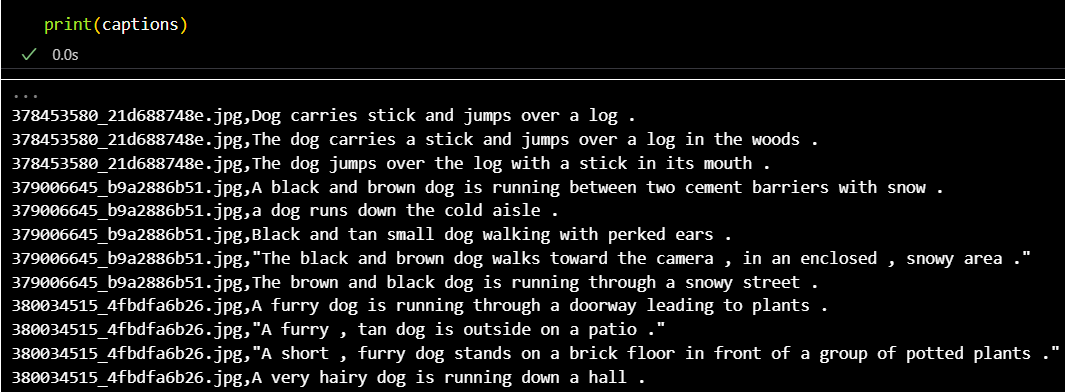

Now, we will create a mapping of image to caption. Since we have 5 captions for every image in the dataset, the mapping for every image will be a list

In [5]:
# an image caption mapping
caption_mapping = {}

for line in captions.split('\n'): #splitting the captions line by line
    # splitting the line into image id and caption
    if len(line) < 2 :
        continue
    caption = line.split(',')
    img_id = caption[0]
    caption = caption[1]
    # removing '.jpg' extension from image id
    img_id = img_id.split('.')[0]
    # create an empty list if it's not present in the mapping
    if img_id not in caption_mapping:
        caption_mapping[img_id] = []
    # append the caption to it's corresponding image id's list
    caption_mapping[img_id].append(caption)

In [6]:
len(caption_mapping)

8091

So, now we have a mapping of image to it's image array and image to it's captions.